How does the HP of 1st-5th gen pokemon compare to 6th-9th gen pokemon?

I'm planning on conducting a census study to answer this question.

In [1]:
import pandas as pd
import seaborn as sns

In [2]:
pokemon = pd.read_csv("pokemon.csv")
pokemon

,national_number,gen,english_name,japanese_name,primary_type,secondary_type,classification,percent_male,percent_female,height_m,...,evochain_1,evochain_2,evochain_3,evochain_4,evochain_5,evochain_6,gigantamax,mega_evolution,mega_evolution_alt,description
0,1,I,Bulbasaur,Fushigidane,grass,poison,Seed Pokémon,87.5,12.5,0.7,...,Level,Ivysaur,Level,Venusaur,NaN,NaN,NaN,NaN,NaN,There is a plant seed on its back right from t...
1,2,I,Ivysaur,Fushigisou,grass,poison,Seed Pokémon,87.5,12.5,1.0,...,Level,Ivysaur,Level,Venusaur,NaN,NaN,NaN,NaN,NaN,"When the bulb on its back grows large, it appe..."
2,3,I,Venusaur,Fushigibana,grass,poison,Seed Pokémon,87.5,12.5,2.0,...,Level,Ivysaur,Level,Venusaur,NaN,NaN,Gigantamax Venusaur,Mega Venusaur,NaN,Its plant blooms when it is absorbing solar en...
3,4,I,Charmander,Hitokage,fire,NaN,Lizard Pokémon,87.5,12.5,0.6,...,Level,Charmeleon,Level,Charizard,NaN,NaN,NaN,NaN,NaN,It has a preference for hot things. When it ra...
4,5,I,Charmeleon,Lizardo,fire,NaN,Flame Pokémon,87.5,12.5,1.1,...,Level,Charmeleon,Level,Charizard,NaN,NaN,NaN,NaN,NaN,"It has a barbaric nature. In battle, it whips ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,1021,IX,Raging Bolt,Takeruraiko,electric,dragon,Paradox Pokémon,NaN,NaN,5.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,It bears resemblance to a Pokémon that became ...
1021,1022,IX,Iron Boulder,Tetsunoiwao,rock,psychic,Paradox Pokémon,NaN,NaN,1.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,It was named after a mysterious object recorde...
1022,1023,IX,Iron Crown,Tetsunokashira,steel,psychic,Paradox Pokémon,NaN,NaN,1.6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,There was supposedly an incident in which it l...
1023,1024,IX,Terapagos,Terapagos,normal,NaN,Tera Pokémon,50.0,50.0,0.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,It’s thought that this Pokémon lived in ancien...


In [3]:
pokemon.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 55 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   national_number     1025 non-null   int64  
 1   gen                 1025 non-null   str    
 2   english_name        1025 non-null   str    
 3   japanese_name       1025 non-null   str    
 4   primary_type        1025 non-null   str    
 5   secondary_type      526 non-null    str    
 6   classification      1025 non-null   str    
 7   percent_male        870 non-null    float64
 8   percent_female      870 non-null    float64
 9   height_m            1025 non-null   float64
 10  weight_kg           1025 non-null   float64
 11  capture_rate        1025 non-null   str    
 12  base_egg_steps      1025 non-null   int64  
 13  hp                  1025 non-null   int64  
 14  attack              1025 non-null   int64  
 15  defense             1025 non-null   int64  
 16  sp_attack        

In [4]:
gens = ['I', 'II', 'III', 'IV', 'V']
gen = pokemon[pokemon['gen'].isin(gens)]
overall_avg = gen['hp'].mean()
print(round(overall_avg, 2))

68.49


In [7]:
gens2 = ['VI', 'VII', 'VIII', 'IX']
gen2 = pokemon[pokemon['gen'].isin(gens)]
overall_avg2 = gen2['hp'].mean()
print(round(overall_avg2, 2))

73.11


In [11]:
gens_1_5 = pokemon[pokemon['gen'].isin(['I', 'II', 'III', 'IV', 'V'])]
gens_6_9 = pokemon[pokemon['gen'].isin(['VI', 'VII', 'VIII', 'IX'])]

gens_1_5['gen_group'] = 'Gens 1-5'
gens_6_9['gen_group'] = 'Gens 6-9'
combined = pd.concat([gens_1_5, gens_6_9])

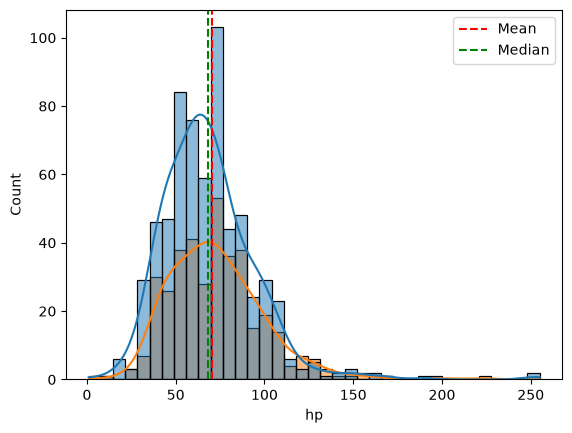

In [13]:
ax = sns.histplot(data=combined, x='hp', hue='gen_group', kde=True)

ax.axvline(combined['hp'].mean(), color='red', linestyle='--', label='Mean')
ax.axvline(combined['hp'].median(), color='green', linestyle='--', label='Median')
ax.legend()

The average hp for gens 1-5 is 68.49 and the average hp for gens 6-9 is 73.11.